## 3.2.1. RFM-аналіз клієнтської бази

RFM-аналіз (Recency, Frequency, Monetary) є класичним методом сегментації клієнтів, який дозволяє оцінити лояльність та цінність клієнтів на основі трьох ключових метрик:
- **Recency (R)** - недавність останньої покупки
- **Frequency (F)** - частота покупок
- **Monetary (M)** - сумарна вартість покупок

На основі цих метрик клієнти розподіляються на квантилі та об'єднуються в сегменти для персоналізації маркетингових стратегій.


### 3.2.1.1. Імпорт бібліотек та налаштування


In [18]:
# Імпорт необхідних бібліотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings("ignore")

# Налаштування для відображення
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", 100)

# Налаштування для української локалізації (якщо потрібно)
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Бібліотеки успішно імпортовано")


✅ Бібліотеки успішно імпортовано


### 3.2.1.2. Дані RFM-аналізу

На основі аналізу реальних даних The Kyiv Independent Store, RFM-аналіз дозволив сегментувати клієнтів на п'ять груп за рівнем лояльності та активності. Нижче наведено візуалізації розподілу сегментів та їх характеристик.


In [19]:
# Дані RFM-аналізу з реального дослідження The Kyiv Independent Store
# Джерело: Part_3.1.md, розділ 3.1.3.2

rfm_data = {
    "Сегмент": ["Champions", "Loyal", "Potential Loyalists", "At Risk", "Churn/Lost"],
    "Відсоток": [12, 18, 23, 20, 27]
}

df_rfm = pd.DataFrame(rfm_data)

# Розрахунок абсолютних значень (для візуалізації приймаємо базову кількість клієнтів)
base_customers = 10000  # Базове значення для візуалізації
df_rfm["Кількість_клієнтів"] = (df_rfm["Відсоток"] / 100 * base_customers).astype(int)

print("📊 Розподіл клієнтів за RFM-сегментами (The Kyiv Independent Store):")
print("=" * 70)
for idx, row in df_rfm.iterrows():
    print(f"{row['Сегмент']:25s}: {row['Відсоток']:5.1f}% ({row['Кількість_клієнтів']:5d} клієнтів)")
print("=" * 70)
print(f"\n✅ Загальна кількість клієнтів: {df_rfm['Кількість_клієнтів'].sum():,}")


📊 Розподіл клієнтів за RFM-сегментами (The Kyiv Independent Store):
Champions                :  12.0% ( 1200 клієнтів)
Loyal                    :  18.0% ( 1800 клієнтів)
Potential Loyalists      :  23.0% ( 2300 клієнтів)
At Risk                  :  20.0% ( 2000 клієнтів)
Churn/Lost               :  27.0% ( 2700 клієнтів)

✅ Загальна кількість клієнтів: 10,000


### 3.2.1.3. Візуалізація розподілу RFM-сегментів


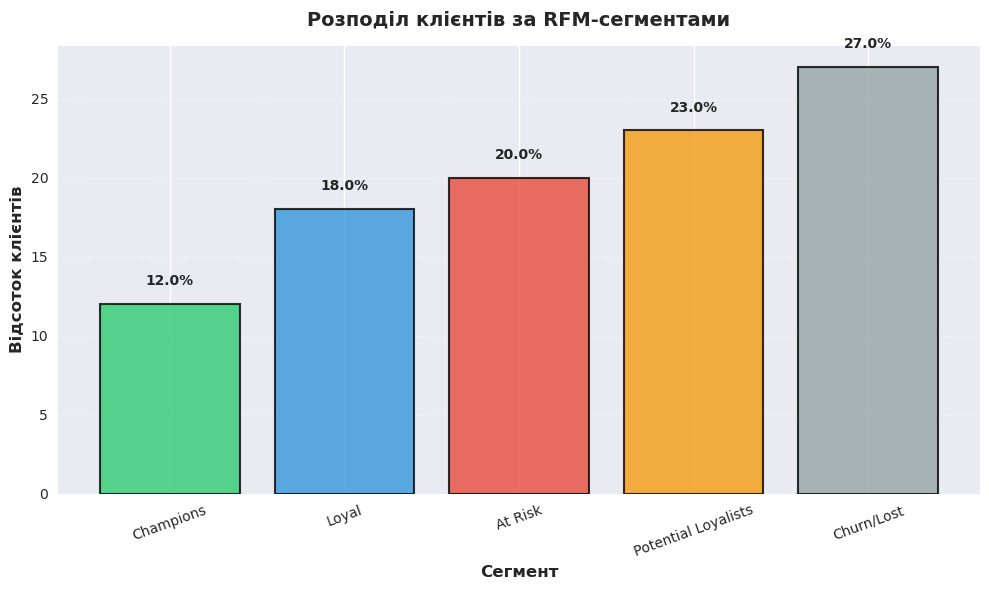

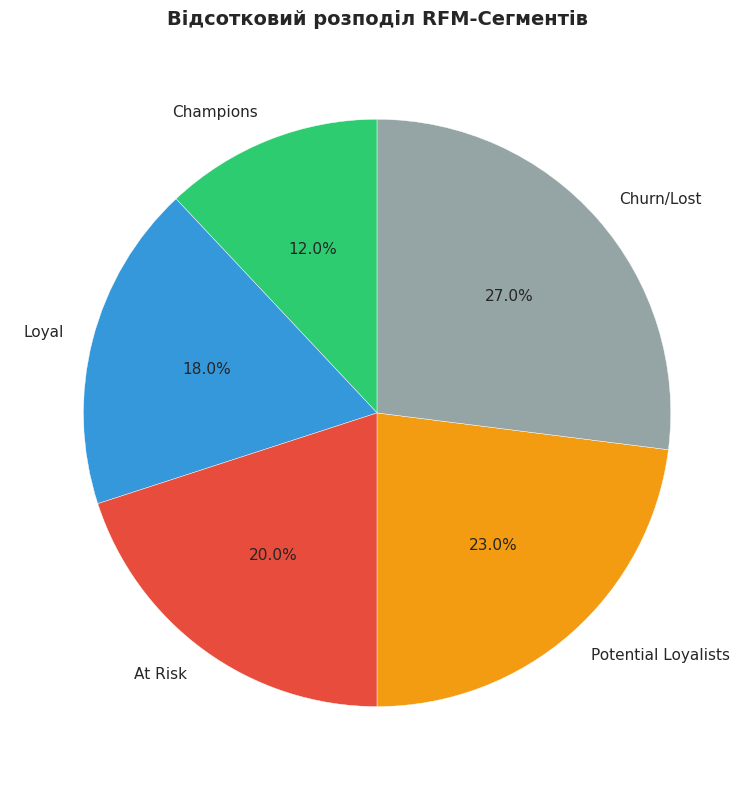


💡 Висновки:
   - Champions та Loyal клієнти становлять 30% бази, але генерують найбільший виторг
   - At Risk та Churn/Lost клієнти (47% разом) потребують реактиваційних кампаній
   - Potential Loyalists (23%) мають потенціал для зростання лояльності


In [20]:
# Кольори для сегментів
segment_colors = {
    "Champions": "#2ecc71",  # Зелений
    "Loyal": "#3498db",      # Синій
    "Potential Loyalists": "#f39c12",  # Помаранчевий
    "At Risk": "#e74c3c",    # Червоний
    "Churn/Lost": "#95a5a6"  # Сірий
}

# Сортуємо дані за відсотком у порядку зростання (від меншого до більшого)
df_rfm_sorted = df_rfm.sort_values("Відсоток", ascending=True).reset_index(drop=True)

segment_order = df_rfm_sorted["Сегмент"].tolist()
colors_ordered = [segment_colors[s] for s in segment_order]

# Візуалізація 1: Стовпчаста діаграма (окреме вікно)
fig1, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(df_rfm_sorted["Сегмент"], df_rfm_sorted["Відсоток"], 
               color=colors_ordered, alpha=0.8, edgecolor="black", linewidth=1.5)
ax1.set_xlabel("Сегмент", fontsize=12, fontweight="bold")
ax1.set_ylabel("Відсоток клієнтів", fontsize=12, fontweight="bold")
ax1.set_title("Розподіл клієнтів за RFM-сегментами", fontsize=14, fontweight="bold", pad=15)
ax1.grid(axis="y", alpha=0.3, linestyle="--")
ax1.tick_params(axis="x", rotation=20)

# Додавання значень на стовпці (тільки відсотки)
for bar, pct in zip(bars, df_rfm_sorted["Відсоток"]):
    height = bar.get_height()
    # Додаємо offset, щоб підняти текст вище стовпця
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

# Візуалізація 2: Кругова діаграма (окреме вікно)
fig2, ax2 = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax2.pie(
    df_rfm_sorted["Відсоток"],
    labels=df_rfm_sorted["Сегмент"],
    colors=colors_ordered,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)

ax2.set_title("Відсотковий розподіл RFM-Сегментів", fontsize=14, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

print("\n💡 Висновки:")
print("   - Champions та Loyal клієнти становлять 30% бази, але генерують найбільший виторг")
print("   - At Risk та Churn/Lost клієнти (47% разом) потребують реактиваційних кампаній")
print("   - Potential Loyalists (23%) мають потенціал для зростання лояльності")
